# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification



## 0. Install dependencies

In [ ]:
!pip install -q kagglehub opencv-python-headless scikit-learn --upgrade

## 1. Dataset preparation — HAM10000



In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", dataset_path)

import os
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        dirs[:] = []

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000
skin-cancer-mnist-ham10000/
  HAM10000_images_part_1/
  ham10000_images_part_1/
  HAM10000_images_part_2/
  ham10000_images_part_2/


In [ ]:
import glob, os
import pandas as pd
import kagglehub

# Added the definition of dataset_path from the previous cell
dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

# Locate the metadata file and the two image folders shipped with the Kaggle version
meta_path = glob.glob(os.path.join(dataset_path, "**", "HAM10000_metadata*.csv"), recursive=True)[0]
meta = pd.read_csv(meta_path)

image_paths = {}
for ext_dir in glob.glob(os.path.join(dataset_path, "**", "*ham10000_images*"), recursive=True):
    for f in glob.glob(os.path.join(ext_dir, "*.jpg")):
        image_paths[os.path.splitext(os.path.basename(f))[0]] = f

meta["path"] = meta["image_id"].map(image_paths)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

CLASS_NAMES = sorted(meta["dx"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
meta["label_idx"] = meta["dx"].map(class_to_idx)

print("Classes:", CLASS_NAMES)
print("Total images found:", len(meta))
print(meta["dx"].value_counts())

100%|██████████| 5.20G/5.20G [04:51<00:00, 19.2MB/s]

Extracting files...


Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total images found: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
# Optional: cap images per class for a lighter / more balanced instructor-approved subset
SUBSET_PER_CLASS = None  # e.g. 300 -- set to None to use the full dataset

if SUBSET_PER_CLASS is not None:
    meta = (meta.groupby("dx", group_keys=False)
                 .apply(lambda g: g.sample(min(len(g), SUBSET_PER_CLASS), random_state=42))
                 .reset_index(drop=True))
    print("Subset size after capping:", len(meta))
    print(meta["dx"].value_counts())

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified 80/10/10 split, matching Lab 01's methodology
train_df, temp_df = train_test_split(meta, test_size=0.2, stratify=meta["label_idx"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label_idx"], random_state=42)

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))
num_classes = len(CLASS_NAMES)

Train / Val / Test sizes: 8012 1001 1002


## 2. Best three pretrained models (from Lab Activity 1)

Fill this in with the **top-3 backbones by test accuracy / F1 from your Task 01 Table 1**
(the ISIC / HAM10000 transfer-learning comparison). The cell below reads
`table1_transfer_learning_models.csv` if you saved it from Lab 01 and auto-selects the top 3;
otherwise it falls back to the manual list so the notebook still runs end-to-end.

In [ ]:
import pandas as pd

# --- Manual fallback: replace with your own Lab 01 findings if the CSV isn't available ---
BEST_MODELS_MANUAL = ["resnet50", "densenet121", "efficientnet_b0"]

lab1_csv = "table1_transfer_learning_models.csv"  # upload this from Lab 01 if you have it
try:
    lab1_df = pd.read_csv(lab1_csv, index_col=0)
    BEST_MODELS = lab1_df.sort_values("Accuracy", ascending=False).head(3).index.str.lower().tolist()
    print("Loaded Lab 01 results — auto-selected best 3:", BEST_MODELS)
except FileNotFoundError:
    BEST_MODELS = BEST_MODELS_MANUAL
    print("Lab 01 CSV not found — using manual best-3 list:", BEST_MODELS)

MODEL_DISPLAY_NAMES = {
    "alexnet": "AlexNet", "vgg16": "VGG16", "vgg19": "VGG19",
    "resnet18": "ResNet18", "resnet50": "ResNet50", "resnet101": "ResNet101",
    "densenet121": "DenseNet121", "efficientnet_b0": "EfficientNet-B0",
}
print("Model 1:", MODEL_DISPLAY_NAMES.get(BEST_MODELS[0], BEST_MODELS[0]))
print("Model 2:", MODEL_DISPLAY_NAMES.get(BEST_MODELS[1], BEST_MODELS[1]))
print("Model 3:", MODEL_DISPLAY_NAMES.get(BEST_MODELS[2], BEST_MODELS[2]))

Lab 01 CSV not found — using manual best-3 list: ['resnet50', 'densenet121', 'efficientnet_b0']
Model 1: ResNet50
Model 2: DenseNet121
Model 3: EfficientNet-B0


## 3. Image filtering functions

Each filter is implemented with OpenCV and applied to the raw RGB image **before** the usual
resize / tensor / normalize pipeline, so every model sees the same filtered input. `"none"` is
the unfiltered baseline.

In [ ]:
import cv2
import numpy as np

def apply_filter(img_rgb, filter_name):
    """img_rgb: HxWx3 uint8 numpy array (RGB). Returns a filtered HxWx3 uint8 RGB array."""
    if filter_name == "none":
        return img_rgb

    if filter_name == "average":
        return cv2.blur(img_rgb, (5, 5))

    if filter_name == "gaussian":
        return cv2.GaussianBlur(img_rgb, (5, 5), sigmaX=1.0)

    if filter_name == "median":
        return cv2.medianBlur(img_rgb, 5)

    if filter_name == "sharpen":
        kernel = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]], dtype=np.float32)
        return cv2.filter2D(img_rgb, -1, kernel)

    if filter_name == "sobel":
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = np.sqrt(gx ** 2 + gy ** 2)
        mag = np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
        return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)  # replicate to 3 channels for the CNNs

    raise ValueError(f"Unknown filter: {filter_name}")

FILTERS = ["none", "average", "gaussian", "median", "sharpen", "sobel"]
FILTER_DISPLAY_NAMES = {
    "none": "No Filter", "average": "Average", "gaussian": "Gaussian",
    "median": "Median", "sharpen": "Sharpening", "sobel": "Sobel",
}

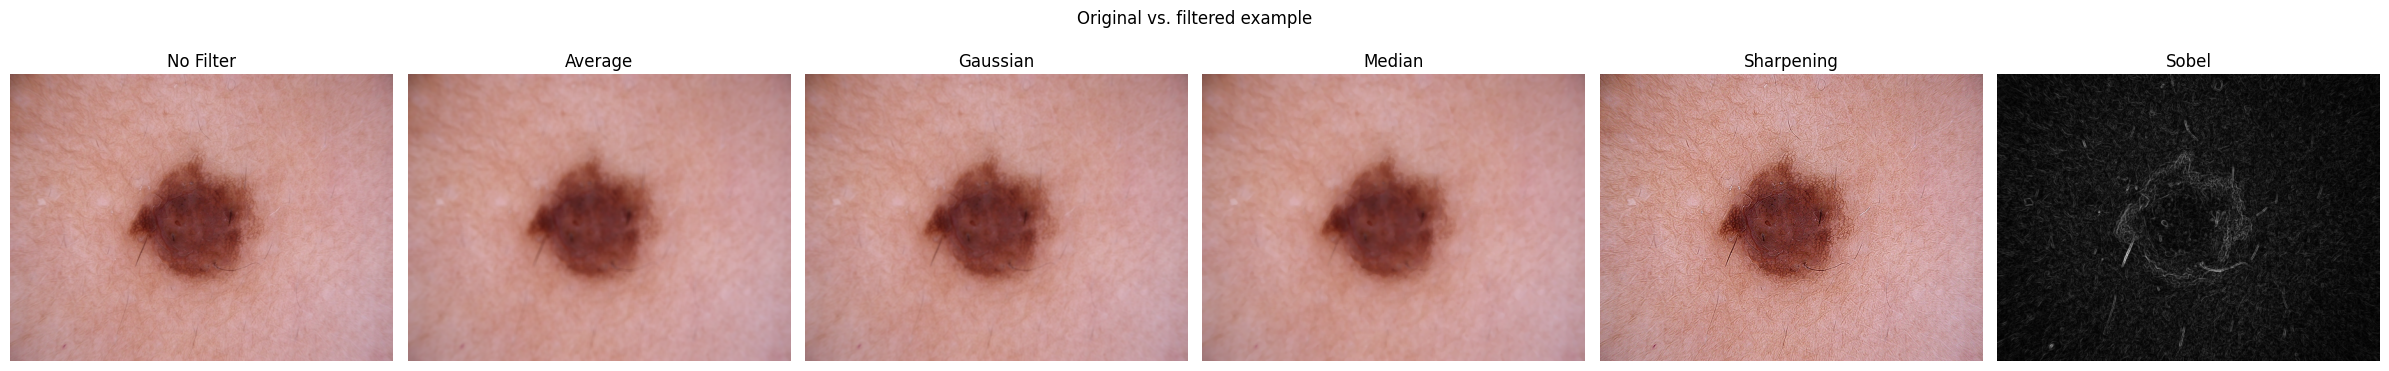

In [ ]:
# --- Visual sanity-check: original vs. every filter, on one sample image ---
import matplotlib.pyplot as plt
from PIL import Image

sample_path = train_df.iloc[0]["path"]
sample_img = np.array(Image.open(sample_path).convert("RGB"))

fig, axes = plt.subplots(1, len(FILTERS), figsize=(4 * len(FILTERS), 4))
for ax, f in zip(axes, FILTERS):
    ax.imshow(apply_filter(sample_img, f))
    ax.set_title(FILTER_DISPLAY_NAMES[f])
    ax.axis("off")
plt.suptitle("Original vs. filtered example")
plt.tight_layout()
plt.savefig("filter_examples.png", dpi=150)
plt.show()

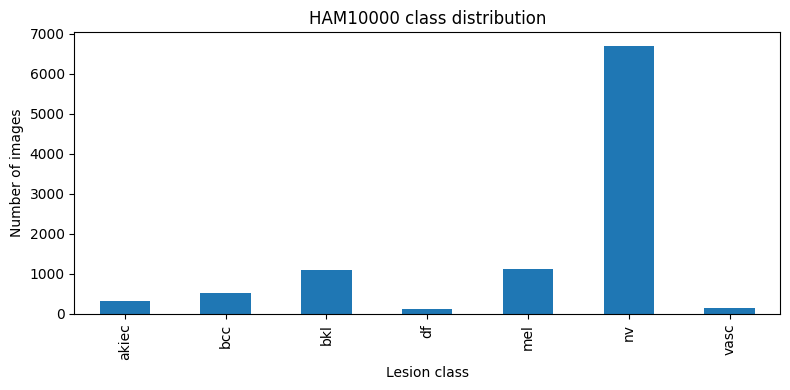

In [ ]:
# --- HAM10000 class distribution ---
plt.figure(figsize=(8, 4))
meta["dx"].value_counts().reindex(CLASS_NAMES).plot(kind="bar")
plt.title("HAM10000 class distribution")
plt.xlabel("Lesion class"); plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## 4. Dataset class & dataloaders (filter-aware)

Same `IMG_SIZE`, augmentation and normalization as Lab 01, but the filter is applied to the
raw image first so it is identical across all models for a given condition.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FilteredSkinLesionDataset(Dataset):
    def __init__(self, dataframe, filter_name="none", transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.filter_name = filter_name
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row["path"]).convert("RGB"))
        img = apply_filter(img, self.filter_name)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, row["label_idx"]

def make_loaders(filter_name):
    train_ds = FilteredSkinLesionDataset(train_df, filter_name, train_tf)
    val_ds = FilteredSkinLesionDataset(val_df, filter_name, eval_tf)
    test_ds = FilteredSkinLesionDataset(test_df, filter_name, eval_tf)
    return (DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
            DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
            DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2))

Using device: cuda


## 5. Model loading (reused from Lab 01)

In [ ]:
import torch.nn as nn
from torchvision import models

def get_model(name, num_classes):
    name = name.lower()
    if name == "alexnet":
        m = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "vgg16":
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "vgg19":
        m = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "resnet101":
        m = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model name: {name}")
    return m

## 6. Training and evaluation routine

Same freeze → fine-tune schedule as Lab 01, kept identical across every (model, filter) run so
the comparison is fair. `evaluate_model` now also returns everything needed for the
"Additional Analysis" section: confusion matrix, per-class precision/recall/F1, macro-F1,
balanced accuracy and AUC.

In [ ]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, balanced_accuracy_score, confusion_matrix,
                              classification_report)

EPOCHS = 8          # raise for a more polished final result
FREEZE_EPOCHS = 2

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=1e-4, freeze_epochs=FREEZE_EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for p in model.parameters():
        p.requires_grad = False
    for p in list(model.parameters())[-2:]:
        p.requires_grad = True
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    for _ in range(freeze_epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()

    for p in model.parameters():
        p.requires_grad = True
    optimizer = torch.optim.Adam(model.parameters(), lr=lr * 0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3)

    best_val_loss = float("inf")
    best_state = None
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, labels)
                val_loss += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += labels.size(0)
        val_loss /= v_total
        val_acc = v_correct / v_total
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
        print(f"    epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}"
              f"  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, data_loader, num_classes, class_names):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(DEVICE)
            probs = torch.softmax(model(imgs), dim=1).cpu().numpy()
            all_preds.extend(probs.argmax(axis=1))
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds) * 100,
        "Precision": precision_score(all_labels, all_preds, average="weighted", zero_division=0) * 100,
        "Recall": recall_score(all_labels, all_preds, average="weighted", zero_division=0) * 100,
        "F1-score": f1_score(all_labels, all_preds, average="weighted", zero_division=0) * 100,
        "Macro-F1": f1_score(all_labels, all_preds, average="macro", zero_division=0) * 100,
        "Balanced-Acc": balanced_accuracy_score(all_labels, all_preds) * 100,
    }
    try:
        metrics["AUC"] = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="weighted") * 100
    except ValueError:
        metrics["AUC"] = float("nan")

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names,
                                    output_dict=True, zero_division=0)
    return metrics, cm, report

## 7. Run the full grid — baseline + 5 filters × 3 best models

This is the core experiment: every one of the three selected backbones is trained **from the
same ImageNet-pretrained weights** six times — once unfiltered, once per filter — with
identical dataset split, preprocessing and training settings (`EPOCHS`, `FREEZE_EPOCHS`,
learning rate, optimizer, scheduler) so the only thing that changes between runs is the input
filter.

In [ ]:
all_results = []          # rows for the final comparison table
all_histories = {}         # (model, filter) -> training history, for the curves
all_confusions = {}        # (model, filter) -> confusion matrix
all_reports = {}           # (model, filter) -> per-class report

for model_name in BEST_MODELS:
    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)
    for filt in FILTERS:
        print(f"\n=== {display_name} | {FILTER_DISPLAY_NAMES[filt]} ===")
        torch.cuda.empty_cache()

        train_loader, val_loader, test_loader = make_loaders(filt)
        model = get_model(model_name, num_classes)
        model, history = train_model(model, train_loader, val_loader)
        metrics, cm, report = evaluate_model(model, test_loader, num_classes, CLASS_NAMES)

        all_results.append({
            "Model": display_name,
            "Filter": FILTER_DISPLAY_NAMES[filt],
            **metrics,
        })
        all_histories[(display_name, filt)] = history
        all_confusions[(display_name, filt)] = cm
        all_reports[(display_name, filt)] = report

        print(f"  -> {metrics}")
        del model
        torch.cuda.empty_cache()


=== ResNet50 | No Filter ===
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


    epoch 1/8  train_loss=0.7142  val_loss=0.5789  train_acc=0.750  val_acc=0.802
    epoch 2/8  train_loss=0.5544  val_loss=0.4974  train_acc=0.800  val_acc=0.831
    epoch 3/8  train_loss=0.4820  val_loss=0.4485  train_acc=0.830  val_acc=0.839
    epoch 4/8  train_loss=0.4257  val_loss=0.4276  train_acc=0.847  val_acc=0.848
    epoch 5/8  train_loss=0.3795  val_loss=0.4057  train_acc=0.867  val_acc=0.856
    epoch 6/8  train_loss=0.3474  val_loss=0.3908  train_acc=0.876  val_acc=0.866
    epoch 7/8  train_loss=0.3063  val_loss=0.3824  train_acc=0.890  val_acc=0.866
    epoch 8/8  train_loss=0.2907  val_loss=0.3767  train_acc=0.897  val_acc=0.871
  -> {'Accuracy': 88.12375249500998, 'Precision': 87.6205950889977, 'Recall': 88.12375249500998, 'F1-score': 87.33076245862779, 'Macro-F1': 80.2251412201314, 'Balanced-Acc': np.float64(79.01738776446037), 'AUC': np.float64(96.99531788984316)}

=== ResNet50 | Average ===
    epoch 1/8  train_loss=0.7178  val_loss=0.6092  train_acc=0.745  val_a

100%|██████████| 30.8M/30.8M [00:00<00:00, 219MB/s]


    epoch 1/8  train_loss=0.7857  val_loss=0.7189  train_acc=0.719  val_acc=0.759
    epoch 2/8  train_loss=0.6610  val_loss=0.6092  train_acc=0.765  val_acc=0.787
    epoch 3/8  train_loss=0.5906  val_loss=0.5469  train_acc=0.792  val_acc=0.811
    epoch 4/8  train_loss=0.5405  val_loss=0.5005  train_acc=0.807  val_acc=0.821
    epoch 5/8  train_loss=0.5069  val_loss=0.4764  train_acc=0.823  val_acc=0.830
    epoch 6/8  train_loss=0.4632  val_loss=0.4432  train_acc=0.833  val_acc=0.835
    epoch 7/8  train_loss=0.4378  val_loss=0.4284  train_acc=0.843  val_acc=0.842
    epoch 8/8  train_loss=0.4140  val_loss=0.4154  train_acc=0.852  val_acc=0.848
  -> {'Accuracy': 85.62874251497006, 'Precision': 85.0403490464545, 'Recall': 85.62874251497006, 'F1-score': 84.77116388246141, 'Macro-F1': 71.51481575242897, 'Balanced-Acc': np.float64(69.26307299258119), 'AUC': np.float64(96.91350015643103)}

=== DenseNet121 | Average ===
    epoch 1/8  train_loss=0.7999  val_loss=0.7189  train_acc=0.717  v

100%|██████████| 20.5M/20.5M [00:00<00:00, 226MB/s]


    epoch 1/8  train_loss=0.8789  val_loss=0.8293  train_acc=0.711  val_acc=0.719
    epoch 2/8  train_loss=0.7894  val_loss=0.7433  train_acc=0.725  val_acc=0.736
    epoch 3/8  train_loss=0.7298  val_loss=0.6938  train_acc=0.745  val_acc=0.758
    epoch 4/8  train_loss=0.6883  val_loss=0.6553  train_acc=0.756  val_acc=0.764
    epoch 5/8  train_loss=0.6569  val_loss=0.6295  train_acc=0.769  val_acc=0.790
    epoch 6/8  train_loss=0.6140  val_loss=0.5987  train_acc=0.789  val_acc=0.791
    epoch 7/8  train_loss=0.5949  val_loss=0.5772  train_acc=0.789  val_acc=0.799
    epoch 8/8  train_loss=0.5688  val_loss=0.5567  train_acc=0.798  val_acc=0.802
  -> {'Accuracy': 81.437125748503, 'Precision': 78.96142723309585, 'Recall': 81.437125748503, 'F1-score': 79.61265706462527, 'Macro-F1': 54.484186740141425, 'Balanced-Acc': np.float64(51.9097120677917), 'AUC': np.float64(94.49747005018473)}

=== EfficientNet-B0 | Average ===
    epoch 1/8  train_loss=0.8868  val_loss=0.8650  train_acc=0.702  

## 8. Required comparison table

Matches the table format from the task sheet: one row per (Model, Filter) combination.

#### **Action Required:**

The `NameError: name 'all_results' is not defined` indicates that the `all_results` variable has not been initialized in the current session. This variable is created by running the extensive experiment loop in the cell above (cell `lrsu81LJcN2x`, under '7. Run the full grid').

Please ensure you run cell `lrsu81LJcN2x` to generate `all_results` before executing the cells in this section.

In [1]:
import pandas as pd

results_df = pd.DataFrame(all_results)
display(results_df.head())
results_df = results_df[["Model", "Filter", "Accuracy", "Precision", "Recall",
                          "F1-score", "Macro-F1", "AUC"]].round(2)
results_df.to_csv("task02_comparison_table.csv", index=False)
results_df

NameError: name 'all_results' is not defined

In [2]:
# Extra columns requested in "Additional Analysis" (Balanced accuracy alongside the main table)
extra_df = pd.DataFrame(all_results)[["Model", "Filter", "Balanced-Acc"]].round(2)
extra_df.to_csv("task02_balanced_accuracy.csv", index=False)
extra_df

NameError: name 'all_results' is not defined

## 9. Visualization

### 9.1 Training / validation accuracy and loss curves (per model, per filter)

In [ ]:
for (display_name, filt), history in all_histories.items():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set_title(f"{display_name} | {FILTER_DISPLAY_NAMES[filt]} — Loss")
    axes[0].set_xlabel("epoch"); axes[0].legend()

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="val")
    axes[1].set_title(f"{display_name} | {FILTER_DISPLAY_NAMES[filt]} — Accuracy")
    axes[1].set_xlabel("epoch"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"curves_{display_name}_{filt}.png", dpi=120)
    plt.show()

### 9.2 Confusion matrices

In [ ]:
import itertools

for (display_name, filt), cm in all_confusions.items():
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"{display_name} | {FILTER_DISPLAY_NAMES[filt]}")
    plt.colorbar()
    ticks = np.arange(len(CLASS_NAMES))
    plt.xticks(ticks, CLASS_NAMES, rotation=45)
    plt.yticks(ticks, CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"confusion_{display_name}_{filt}.png", dpi=120)
    plt.show()

### 9.3 Per-class precision / recall / F1-score

In [ ]:
for (display_name, filt), report in all_reports.items():
    per_class = pd.DataFrame(report).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]
    print(f"\n--- {display_name} | {FILTER_DISPLAY_NAMES[filt]} ---")
    display(per_class.round(3))

### 9.4 Filter effect summary (per model)

In [ ]:
pivot_acc = results_df.pivot(index="Filter", columns="Model", values="Accuracy")
pivot_acc = pivot_acc.reindex([FILTER_DISPLAY_NAMES[f] for f in FILTERS])
pivot_acc.plot(kind="bar", figsize=(9, 4))
plt.title("Test accuracy by filter, per model")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.savefig("filter_effect_summary.png", dpi=150)
plt.show()

pivot_macrof1 = results_df.pivot(index="Filter", columns="Model", values="Macro-F1")
pivot_macrof1 = pivot_macrof1.reindex([FILTER_DISPLAY_NAMES[f] for f in FILTERS])
pivot_macrof1.plot(kind="bar", figsize=(9, 4))
plt.title("Macro-F1 by filter, per model")
plt.ylabel("Macro-F1 (%)")
plt.tight_layout()
plt.savefig("filter_effect_macro_f1.png", dpi=150)
plt.show()

## 10. Comparative analysis — does filtering affect the 3 models consistently?

The cell below computes, for each model, the change in Accuracy and Macro-F1 relative to its
own "No Filter" baseline. Run it after the grid above finishes to fill in the actual numbers
before writing your discussion.

In [ ]:
baseline = results_df[results_df["Filter"] == "No Filter"].set_index("Model")

delta_rows = []
for _, row in results_df.iterrows():
    if row["Filter"] == "No Filter":
        continue
    base = baseline.loc[row["Model"]]
    delta_rows.append({
        "Model": row["Model"],
        "Filter": row["Filter"],
        "Δ Accuracy": round(row["Accuracy"] - base["Accuracy"], 2),
        "Δ Macro-F1": round(row["Macro-F1"] - base["Macro-F1"], 2),
        "Δ AUC": round(row["AUC"] - base["AUC"], 2),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv("task02_delta_vs_baseline.csv", index=False)
delta_df

## 11. Answers to the conceptual questions

Update the numeric claims (in *italics*, marked `<- fill in`) once the grid above has finished
running on your dataset/subset — the reasoning below is general and applies regardless of the
exact numbers.

**1. Which three pretrained models performed best in Lab Activity 1?**
*`<- fill in with your BEST_MODELS from Section 2 / Lab 01 Table 1>`*

**2. How does filtering affect each of the three models?**
Inspect `delta_df` above: for each model, list which filters increased vs. decreased Accuracy
and Macro-F1 relative to its own "No Filter" row. In general, smoothing filters (Average,
Gaussian, Median) tend to *reduce* fine-grained texture cues, while Sharpening and Sobel change
how much edge/boundary information dominates the input.

**3. Which filter produces the greatest change compared with the unfiltered baseline?**
*`<- read off the largest |Δ Accuracy| / |Δ Macro-F1| in delta_df, per model>`* — commonly the
Sobel filter, since it discards colour and most texture entirely and keeps only edges, but
confirm this against your own results.

**4. Does the effect of a filter remain consistent across all three models?**
Compare the sign/magnitude of `Δ Accuracy` for the same filter across the three models in
`delta_df`. If the direction (improve/hurt) and rough magnitude match, the effect is consistent;
if one architecture is hurt while another is helped by the same filter, the effect is
architecture-dependent — this is common because different backbones (e.g. shallow AlexNet-style
vs. deep residual/dense connections) weight low-level texture vs. high-level shape differently.

**5. Does filtering improve or decrease macro-F1 and balanced accuracy?**
*`<- summarise from delta_df and extra_df>`* — pay particular attention to whether a filter that
helps overall Accuracy still helps Macro-F1/Balanced-Accuracy, since HAM10000 is heavily
imbalanced (the `nv` class dominates) and Accuracy alone can hide poor minority-class
performance.

**6. Which lesion classes are most affected by filtering?**
Compare the per-class precision/recall/F1 tables (Section 9.3) for "No Filter" vs. each filter,
per model. Classes that rely on fine pigment-network texture or colour (e.g. `mel`, `bkl`) are
typically more sensitive to smoothing filters than classes distinguished mainly by shape.

**7. Why might smoothing remove useful lesion texture or morphological information?**
Average/Gaussian/Median filters are low-pass: they average out high-frequency spatial detail.
Dermoscopic diagnosis often depends on exactly that high-frequency detail — pigment network
patterns, fine granularity, dot/globule structures — so smoothing can blur away the very texture
cues a CNN's early convolutional layers learn to detect, pushing the network toward relying on
coarser shape and colour-blob information instead.

**8. Why might sharpening or edge detection help or hurt classification?**
Sharpening amplifies high-frequency content (edges and noise alike), which can make lesion
borders and texture more salient — potentially helpful for boundary-dependent classes — but it
also amplifies imaging noise and artefacts (hairs, ruler marks, illumination vignetting), which
can hurt generalisation. Sobel goes further and discards colour and smooth-texture information
entirely, keeping only edge magnitude; this can help when the diagnosis is mostly about lesion
*shape*/border irregularity, but hurts when diagnosis depends on colour or fine internal texture
that Sobel throws away.

**9. What is the difference between convolution and correlation?**
Cross-correlation slides a kernel over the image and computes a weighted sum directly with the
kernel as given. Convolution does the same but first flips the kernel both horizontally and
vertically (180° rotation) before sliding it. For symmetric kernels (e.g. a Gaussian, an average
box filter) the two operations are identical; for asymmetric kernels (e.g. a Sobel kernel) they
differ. Most deep-learning frameworks implement "convolution" layers as cross-correlation in
practice (no kernel flip) since the kernel weights are learned anyway and the flip has no effect
on what the network can represent — but the classical image-processing filters in this notebook
(via `cv2.filter2D`, `Sobel`, etc.) follow the true, flipped definition.

**10. Relationship between classical image processing and deep-learning-based feature
extraction.**
Classical filters (mean/Gaussian/median/sharpen/Sobel) are *fixed, hand-designed* linear (or
simple non-linear, for median) operators that extract one specific type of information — a
smoothed average, an edge magnitude, etc. — regardless of what is actually useful for the task.
A CNN's convolutional layers are the *same mathematical operation* (2-D correlation of a small
kernel over the image) but with kernel weights **learned from data** to extract whatever
features minimize the classification loss, and are composed hierarchically (edges → textures →
parts → whole-lesion patterns) across many layers. Pre-filtering with a classical operator
effectively hard-codes one particular feature-extraction step *before* the network, which can
help if that fixed operator happens to emphasise information relevant to the diagnosis (as our
results in `delta_df` show for certain model/filter pairs), or hurt if it discards information
the network would otherwise have learned to exploit on its own. In short, classical filters are
a special case of a single, fixed, non-trainable convolutional layer, whereas deep learning
generalises this idea into many trainable, task-optimised layers.

## 12. Save all artifacts

Everything needed for the report (tables, figures) is written to the working directory so it
can be committed to the GitHub Lab 02 folder alongside this notebook.

In [ ]:
import glob as _glob
print("Saved files:")
for f in sorted(_glob.glob("*.csv") + _glob.glob("*.png")):
    print(" -", f)

# Uncomment on Colab to download everything as a zip:
# import shutil
# shutil.make_archive("lab02_outputs", "zip", ".", base_dir=".")
# from google.colab import files
# files.download("lab02_outputs.zip")